# Langchain - Core components

<div class="alert alert-block alert-info">

Resources:

- https://docs.langchain.com/oss/python/langchain/overview
- https://www.youtube.com/watch?v=vzJOAnwIokM
- https://www.youtube.com/watch?v=J7j5tCB_y4w

</div>

In [2]:
"""                     Import libraries.                       """
import os
import requests
from dotenv import load_dotenv
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain.agents import create_agent
from IPython.display import display

In [3]:

"""                     Setup.                       """
# Load environment variables from .env file.
load_dotenv()
os.environ["NVIDIA_API_KEY"] = os.getenv("NVIDIA_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Create the model_llm instance with NVIDIA model
model_llm = ChatNVIDIA(model="meta/llama-3.1-405b-instruct")

```python
ChatNVIDIA.get_available_models()
# model_llm.get_available_models()
```

## 1. Agents

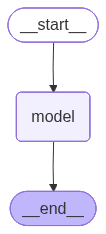

In [3]:
agent = create_agent(
    model=model_llm,
    tools=[],
    system_prompt="You are a helpful assistant."
)
display(agent)

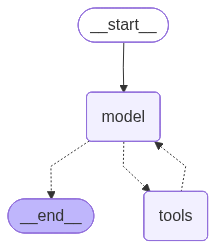

In [4]:
# Define a simple tool/function to get the weather for a city.
'''
def get_weather(city: str) -> str:
    """Get the current weather for a given city."""
    response = requests.get(f"https://wttr.in/{city}?format=j1")
    return response.json()
'''
def get_weather(city: str) -> str:
    """Get the current weather for a given city."""
    response = f"The current weather in {city} is sunny with a temperature of 25°C."
    return response

# Create an agent with the weather tool.
agent_with_tool = create_agent(
    model=model_llm,
    tools=[get_weather],
    system_prompt="You are a helpful weather assistant, who always cracks jokes and is humrous while remaining helpful."
)
display(agent_with_tool)

In [5]:
# Run the agent with a query.
response = agent_with_tool.invoke({
    "messages": [
        {
            "role": "user",
            "content": "What is the current weather in New York?"
        }
    ]
})

print(response)
print(f"\n{'=' * 100}\n")
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='What is the current weather in New York?', additional_kwargs={}, response_metadata={}, id='d894117e-83ff-4c3e-95fb-b8c86a56c571'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'chatcmpl-tool-9e99aea708bbc973', 'type': 'function', 'function': {'name': 'get_weather', 'arguments': '{"city": "New York"}'}}]}, response_metadata={'role': 'assistant', 'content': None, 'refusal': None, 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': [{'id': 'chatcmpl-tool-9e99aea708bbc973', 'type': 'function', 'function': {'name': 'get_weather', 'arguments': '{"city": "New York"}'}}], 'reasoning': None, 'reasoning_content': None, 'token_usage': {'prompt_tokens': 203, 'total_tokens': 222, 'completion_tokens': 19, 'prompt_tokens_details': None}, 'finish_reason': 'tool_calls', 'model_name': 'meta/llama-3.1-405b-instruct'}, id='lc_run--019d2c1a-f15d-7f31-8422-9207ce534f1e-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New Yor

In [6]:
# Alternate way to run the agent with a query.
response = agent_with_tool.invoke(
    {
        "messages": "What is the current weather in New York?"
    }
)
print(response['messages'][-1].content)

The current weather in New York is sunny with a temperature of 25°C.


## 2. Models

LLMs are powerful AI tools that can interpret and generate text like humans. They’re versatile enough to write content, translate languages, summarize, and answer questions without needing specialized training for each task.

In addition to text generation, many models support:

- `Tool calling` - calling external tools (like databases queries or API calls) and use results in their responses.
- `Structured output` - where the model’s response is constrained to follow a defined format.
- `Multimodality` - process and return data other than text, such as images, audio, and video.
- `Reasoning` - models perform multi-step reasoning to arrive at a conclusion.

`Models` are the reasoning engine of agents. They drive the agent’s decision-making process, determining which tools to call, how to interpret results, and when to provide a final answer.

Models can be utilized in two ways:

- `With agents` - Models can be dynamically specified when creating an agent.
- `Standalone` - Models can be called directly (outside of the agent loop) for tasks like text generation, classification, or extraction without the need for an agent framework.

Key methods of a `model` class object are `invoke`, `stream` and `batch`.

### 2.1. Invocation

#### 2.1.1. Invoke

The most straightforward way to call a model is to use `invoke()` with a single message or a list of messages.

In [11]:
from langchain.chat_models import init_chat_model

# Initialize different chat models from various providers.
"""
model = init_chat_model(model="nvidia:meta/llama-3.1-405b-instruct")
model = init_chat_model(model="groq:llama-3.3-70b-versatile")
"""
# model = init_chat_model(model="google_genai:gemini-2.5-flash-lite")
model = init_chat_model(model="google_genai:gemini-2.5-flash")

# Invoke the models with a simple query.
query = "What is the capital of France?"
response = model.invoke(query)

# Print the responses.
print(f"Response:    {response.content}")

Response:    The capital of France is **Paris**.


In [12]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Directly initialize and invoke the models.
"""
from langchain_groq import ChatGroq

model = ChatNVIDIA(model="meta/llama-3.1-405b-instruct")
model = ChatGroq (model="llama-3.3-70b-versatile")
"""
# model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

# Invoke the models with a simple query.
query = "What is the capital of Australia?"
response = model.invoke(query)

# Print the responses.
print(f"Response:    {response.content}")

Response:    The capital of Australia is **Canberra**.


Parameters

A chat model takes parameters that can be used to configure its behavior. he full set of supported parameters varies by model and provider, but standard ones include `model`, `api_key`, `temperature`, `max_tokens`, `timeout`and `max_retries`.

Using `init_chat_model`, pass these parameters as inline `**kwargs`:

```python
model = init_chat_model(
    "claude-sonnet-4-6",
    # kwargs passed to the model.
    temperature=0.7,
    timeout=30,
    max_tokens=1000,
    max_retries=6,  # default
)
```

#### 2.1.2. Stream

Most models can stream their output content while it is being generated. By displaying output progressively, streaming significantly improves user experience, particularly for longer responses.

Calling `stream()` returns an iterator that yields output chunks as they are produced. 

In [14]:
model = ChatNVIDIA(model="meta/llama-3.1-405b-instruct")

# Model response with streaming response.
query = "Tell me a joke."
model.invoke(query)
# model.stream(query)

# basic text streaming.
for chunk in model.stream(query):
    print(chunk.content, end="|", flush=True)

print(f"\n{'='*100}\n")

# Stream tool calls, reasoning and other contents.
for chunk in model.stream(query):
    for block in chunk.content_blocks:
        if block["type"] == "reasoning" and (reasoning := block.get("reasoning")):
            print(f"Reasoning: {reasoning}")
        elif block["type"] == "tool_call_chunk":
            print(f"Tool call chunk: {block}")
        elif block["type"] == "text":
            print(block["text"])
        else:
            pass

|A| man| walked| into| a| library| and| asked| the| librarian|,| "|Do| you| have| any| books| on| Pav|lov|'s| dogs| and| Sch|r|ö|d|inger|'s| cat|?"

|The| librarian| replied|,| "|It| rings| a| bell|,| but| I|'m| not| sure| if| it|'s| here| or| not|."||||

A
 man
 walked
 into
 a
 library
 and
 asked
 the
 librarian
,
 "
Do
 you
 have
 any
 books
 on
 Pav
lov
's
 dogs
 and
 Sch
r
ö
d
inger
's
 cat
?"
 


The
 librarian
 replied
,
 "
It
 rings
 a
 bell
,
 but
 I
'm
 not
 sure
 if
 it
's
 here
 or
 not
."


As opposed to `invoke()`, which returns a single `AIMessage` after the model has finished generating its full response, `stream()` returns multiple `AIMessageChunk` objects, each containing a portion of the output text. Importantly, each chunk in a stream is designed to be gathered into a full message via summation:

```python
full = None  # None | AIMessageChunk
for chunk in model.stream("What color is the sky?"):
    full = chunk if full is None else full + chunk
    print(full.text)

print(f"\n{'='*100}\n")
print(full.content_blocks)
```

#### 2.1.3. Batch

Batching a collection of independent requests to a model can significantly improve performance and reduce costs, as the processing can be done in parallel.

In [15]:
# Model response with batch queries.
queries = [
    "What is large language model?", 
    "What is AI?", 
    "What is the meaning of life?"
]
responses = model.batch(queries)
for i, response in enumerate(responses):
    print(f"Query: {queries[i]}\nResponse: {response.content}\n\n{'=' * 100}\n")

Query: What is large language model?
Response: A large language model (LLM) is a type of artificial intelligence (AI) model that is designed to process and understand human language at a large scale. It is a deep learning model that is trained on vast amounts of text data, which enables it to learn patterns, relationships, and structures of language.

Large language models are typically based on transformer architecture, which is a type of neural network designed specifically for natural language processing (NLP) tasks. These models are trained using a technique called masked language modeling, where some of the words in the input text are randomly replaced with a mask token, and the model is trained to predict the original word.

The key characteristics of large language models are:

1. **Size**: They are trained on massive amounts of text data, often billions of words or more.
2. **Complexity**: They have millions or billions of parameters, which are the internal variables that the m

By default, `batch()` will only return the final output for the entire batch. If you want to receive the output for each individual input as it finishes generating, you can stream results with `batch_as_completed()`.

```python
responses = model.batch_as_completed(queries)
for i, response in enumerate(responses):
    print(f"Query: {queries[i]}\nResponse: {response}\n\n{'=' * 100}\n")
```

When processing a large number of inputs using `batch()` or `batch_as_completed()`, you may want to control the maximum number of parallel calls. This can be done by setting the `max_concurrency` attribute in the `RunnableConfig` dictionary.

```python
responses = model.batch(
    inputs=queries,
    config={
        'max_concurrency':2,  # limit to 2 parallel calls
    }
)
for i, response in enumerate(responses):
    print(f"Query: {query[i]}\nResponse: {response.content}\n\n{'=' * 100}\n")
```

### 2.2. Tool calling

Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code. Tools are pairings of:

- A `schema`, including the name of the tool, a description, and/or argument definitions (often a JSON schema)
- A `function` or coroutine to execute.

Here’s the basic tool calling flow between a user and a model:

<div>
<img src="../../docs/i-tutorials/i-lc-tools.png" width="800"/>
</div>

- 
    ```python
    from IPython.display import Image, display
    display(Image('docs/i-tutorials/i-lc-tools.png', width=800))
    ```

To make tools that you have defined available for use by a model, you must bind them using `bind_tools`. In subsequent invocations, the model can choose to call any of the bound tools as needed.

Some model providers offer built-in tools that can be enabled via model or invocation parameters (e.g. `ChatOpenAI`, `ChatAnthropic`).

Either have docstring in the function definition or use the @tool decorator to add description and metadata to the tool.

- 
    ```python
    @tool('get_weather', description="Get the current weather for a given city.", return_direct=False)
    def get_weather(city: str) -> str:
        '''Get the current weather for a given city.'''
        response = requests.get(f"https://wttr.in/{city}?format=j1")
        return response.json()
    ```

In [42]:
from langchain.tools import tool

# Define a tool/function to get the weather for a city.
@tool
def get_weather(location: str) -> str:
    """Get the weather at a location."""
    return f"It's sunny in {location}."

# Bind the tool to the model and invoke it with a query that requires the tool.
model_with_tools = model.bind_tools(tools=[get_weather])

response = model_with_tools.invoke("What's the weather like in Boston?")
print(response)
print(f"\n{'=' * 100}\n")

for tool_call in response.tool_calls:
    # View tool calls made by the model.
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

content='' additional_kwargs={'tool_calls': [{'id': '4etjkvm9e', 'function': {'arguments': '{"location":"Boston"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 220, 'total_tokens': 234, 'completion_time': 0.044292908, 'completion_tokens_details': None, 'prompt_time': 0.013185261, 'prompt_tokens_details': None, 'queue_time': 0.213758884, 'total_time': 0.057478169}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_e65acd3773', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d3469-48ed-70c0-b055-ea715f4a3086-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': '4etjkvm9e', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 220, 'output_tokens': 14, 'total_tokens': 234}


Tool: get_weather
Args: {'location': 'Boston'}


Below, are some common ways to use tool calling.

- __Tool execution loop__

    When a model returns tool calls, you need to execute the tools and pass the results back to the model. This creates a conversation loop where the model can use tool results to generate its final response. LangChain includes agent abstractions that handle this orchestration for you.

    Here’s a simple example of how to do this:

    - 
        ```python
        # Bind (potentially multiple) tools to the model.
        model_with_tools = model.bind_tools([get_weather])

        # Step 1: Model generates tool calls.
        messages = [{"role": "user", "content": "What's the weather in Boston?"}]
        ai_msg = model_with_tools.invoke(messages)
        messages.append(ai_msg)

        # Step 2: Execute tools and collect results
        for tool_call in ai_msg.tool_calls:
            # Execute the tool with the generated arguments
            tool_result = get_weather.invoke(tool_call)
            messages.append(tool_result)

        # Step 3: Pass results back to model for final response.
        final_response = model_with_tools.invoke(messages)
        print(final_response.text)
        # "The current weather in Boston is 72°F and sunny."

        print(f"\n{'='*100}\n")
        print(messages)
        ```

- __Forcing tool calls__

    By default, the model has the freedom to choose which bound tool to use based on the user’s input. However, you might want to force choosing a tool, ensuring the model uses either a particular tool or any tool from a given list:

    - 
        ```python
        # Force use of any tool.
        model_with_tools = model.bind_tools([tool_1], tool_choice="any")

        # Force use of specific tool.
        model_with_tools = model.bind_tools([tool_1], tool_choice="tool_1")
        ```

- __Parallel tool calls__

    Many models support calling multiple tools in parallel when appropriate. This allows the model to gather information from different sources simultaneously.

    - 
        ```python
        model_with_tools = model.bind_tools([get_weather])

        response = model_with_tools.invoke(
            "What's the weather in Boston and Tokyo?"
        )

        # The model may generate multiple tool calls.
        print(response.tool_calls)
        
        # Execute all tools (can be done in parallel with async).
        results = []
        for tool_call in response.tool_calls:
            if tool_call['name'] == 'get_weather':
                result = get_weather.invoke(tool_call)
            ...
            results.append(result)
        ```

    Most models supporting tool calling enable parallel tool calls by default. Some (including `OpenAI` and `Anthropic`) allow you to disable this feature. To do this, set `parallel_tool_calls=False`.
    
    - 
        ```python
        model.bind_tools([get_weather], parallel_tool_calls=False)
        ```

- __Streaming tool calls__

    When streaming responses, tool calls are progressively built through `ToolCallChunk`. This allows you to see tool calls as they’re being generated rather than waiting for the complete response.

    - 
        ```python
        for chunk in model_with_tools.stream(
            "What's the weather in Boston and Tokyo?"
        ):
            # Tool call chunks arrive progressively
            for tool_chunk in chunk.tool_call_chunks:
                if name := tool_chunk.get("name"):
                    print(f"Tool: {name}")
                if id_ := tool_chunk.get("id"):
                    print(f"ID: {id_}")
                if args := tool_chunk.get("args"):
                    print(f"Args: {args}")
        ```

    You can accumulate chunks to build complete tool calls.
    
    - 
        ```python
        # Accumulate tool calls
        gathered = None
        for chunk in model_with_tools.stream("What's the weather in Boston?"):
            gathered = chunk if gathered is None else gathered + chunk
            print(gathered.tool_calls)
        ```

### 2.2. Structured output

TBC

## 3. Messages

Messages are the fundamental unit of context for models in LangChain. They represent the input and output of models, carrying both the content and metadata needed to represent the state of a conversation when interacting with an LLM.

Messages are objects that contain:

- __👨‍💼Role__ - Identifies the message type (e.g. `system`, `user`)
- __🗂️Content__ - Represents the actual content of the message (like text, images, audio, documents, etc.)
- __🏷️Metadata__ - Optional fields such as response information, message IDs, and token usage

LangChain provides a standard message type that works across all model providers, ensuring consistent behavior regardless of the model being called.

### 3.1. Basic usage

The simplest way to use messages is to create message objects and pass them to a model when invoking.

In [ ]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, SystemMessage

model = init_chat_model(model="groq:llama-3.3-70b-versatile")

system_msg = SystemMessage("You are a helpful assistant.")
human_msg = HumanMessage("Hello, how are you?")

# Use with chat models.
messages = [system_msg, human_msg]
response = model.invoke(messages)  # returns AIMessage
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content="Hello! I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 47, 'total_tokens': 111, 'completion_time': 0.116569789, 'completion_tokens_details': None, 'prompt_time': 0.00179536, 'prompt_tokens_details': None, 'queue_time': 0.223952498, 'total_time': 0.118365149}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_e65acd3773', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d3094-97e8-7501-8659-3e84a224413d-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 47, 'output_tokens': 64, 'total_tokens': 111}


Response content:
Hello! I'm doing well, thank you for asking. I'm a la

#### 3.1.1. Text prompts

Text prompts are strings - ideal for straightforward generation tasks where you don’t need to retain conversation history.

Use text prompts when:

- You have a single, standalone request
- You don’t need conversation history
- You want minimal code complexity

In [24]:
response = model.invoke("Write a haiku about spring")
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content="Blooms of color rise\nGentle breezes whisper sweet\nSpring's warm gentle kiss" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 41, 'total_tokens': 61, 'completion_time': 0.037810636, 'completion_tokens_details': None, 'prompt_time': 0.012448426, 'prompt_tokens_details': None, 'queue_time': 0.451622935, 'total_time': 0.050259062}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d3096-18f1-7e81-9412-f1474c1fbfaf-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 41, 'output_tokens': 20, 'total_tokens': 61}


Response content:
Blooms of color rise
Gentle breezes whisper sweet
Spring's warm gentle kiss


#### 3.1.2. Message prompts

You can also pass in a list of messages to the model by providing a list of message objects.

Use message prompts when:

- Managing multi-turn conversations
- Working with multimodal content (images, audio, files)
- Including system instructions

In [25]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage("You are a poetry expert"),
    HumanMessage("Write a haiku about spring"),
    AIMessage("Cherry blossoms bloom...")
]
response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content=" \nDancing petals soften air \nSpring's sweet gentle kiss" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 52, 'total_tokens': 65, 'completion_time': 0.044308573, 'completion_tokens_details': None, 'prompt_time': 0.003191241, 'prompt_tokens_details': None, 'queue_time': 0.379833685, 'total_time': 0.047499814}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d3098-b63d-7882-a841-3b63174486e4-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 52, 'output_tokens': 13, 'total_tokens': 65}


Response content:
 
Dancing petals soften air 
Spring's sweet gentle kiss


#### 3.1.3. Dictionary format

You can also specify messages directly in `OpenAI` chat completions format.

In [27]:
messages = [
    {"role": "system", "content": "You are a poetry expert"},
    {"role": "user", "content": "Write a haiku about spring"},
    {"role": "assistant", "content": "Cherry blossoms bloom..."}
]
response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content=" \nMorning sun's warm gentle kiss \nSpring's sweet gentle dance" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 52, 'total_tokens': 66, 'completion_time': 0.040541472, 'completion_tokens_details': None, 'prompt_time': 0.005713215, 'prompt_tokens_details': None, 'queue_time': 0.355686878, 'total_time': 0.046254687}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d309a-051d-74f3-91bb-4d153b73d8b9-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 52, 'output_tokens': 14, 'total_tokens': 66}


Response content:
 
Morning sun's warm gentle kiss 
Spring's sweet gentle dance


### 3.2. Message types

- __⚙System message__ - Tells the model how to behave and provide context for interactions
- __👨‍💼Human message__ - Represents user input and interactions with the model
- __🤖AI message__ - Responses generated by the model, including text content, tool calls, and metadata
- __🔧Tool message__ - Represents the outputs of tool calls

#### 3.2.1. System message

A `SystemMessage` represent an initial set of instructions that primes the model’s behavior. You can use a system message to set the tone, define the model’s role, and establish guidelines for responses.

In [28]:
# Basic instructions.
system_msg = SystemMessage("You are a helpful coding assistant.")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content='Creating a REST API\n====================\n### Overview\n\nA REST (Representational State of Resource) API is an architectural style for designing networked applications. It is based on the idea of resources, which are identified by URIs, and can be manipulated using a fixed set of operations.\n\n### Prerequisites\n\n* Programming language (e.g., Python, Java, Node.js)\n* Web framework (e.g., Flask, Django, Express.js)\n* Database (e.g., MySQL, MongoDB, PostgreSQL)\n\n### Steps to Create a REST API\n\n1. **Define the API Endpoints**: Determine the resources that will be exposed through the API and the operations that can be performed on them.\n2. **Choose a Web Framework**: Select a web framework that supports REST API development, such as Flask or Django for Python, or Express.js for Node.js.\n3. **Design the API Routes**: Define the API routes, including the HTTP methods (GET, POST, PUT, DELETE) and the URI paths.\n4. **Implement the API Endpoints**: Write the code

In [29]:
# Detailed persona.
from langchain.messages import SystemMessage, HumanMessage

system_msg = SystemMessage("""
You are a senior Python developer with expertise in web frameworks.
Always provide code examples and explain your reasoning.
Be concise but thorough in your explanations.
""")

messages = [
    system_msg,
    HumanMessage("How do I create a REST API?")
]
response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content='**Creating a REST API with Python and Flask**\n====================================================\n\n### Introduction\n\nA REST (Representational State of Resource) API is an architectural style for designing networked applications. It\'s based on the idea of resources, which are identified by URIs, and can be manipulated using a fixed set of operations.\n\n### Prerequisites\n\n* Python 3.8 or higher\n* Flask 2.0 or higher\n* A code editor or IDE\n\n### Step 1: Install Flask\n\nTo create a REST API, we\'ll use the Flask web framework. First, install Flask using pip:\n```bash\npip install flask\n```\n### Step 2: Create a New Flask App\n\nCreate a new Python file, e.g., `app.py`, and add the following code:\n```python\nfrom flask import Flask, jsonify, request\n\napp = Flask(__name__)\n\n# Sample in-memory data store\ndata = {\n    1: {"name": "John Doe", "age": 30},\n    2: {"name": "Jane Doe", "age": 25}\n}\n\n# GET /users\n@app.route(\'/users\', methods=[\'GET\'])

#### 3.2.2. Human message

A `HumanMessage` represents user input and interactions. They can contain text, images, audio, files, and any other amount of multimodal content.

_Text content_

In [30]:
# Message object.
response = model.invoke([
  HumanMessage("What is machine learning?")
])

print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content='**Machine Learning Overview**\n================================\n\nMachine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform tasks without being explicitly programmed. It allows systems to learn from data, identify patterns, and make decisions or predictions with minimal human intervention.\n\n**Key Characteristics:**\n\n1. **Data-Driven**: Machine learning relies on large datasets to train and improve the performance of models.\n2. **Self-Improvement**: Machine learning models can adapt and improve over time as they receive new data.\n3. **Pattern Recognition**: Machine learning algorithms can identify complex patterns in data, enabling predictive modeling and decision-making.\n\n**Types of Machine Learning:**\n\n1. **Supervised Learning**: The model is trained on labeled data, where the correct output is already known.\n2. **Unsupervised Learning**: The model is trained on u

In [ ]:
# Using a string as a shortcut for a single HumanMessage.
response = model.invoke("What is machine learning?")

print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")

Response:
content='**Machine Learning Definition**\nMachine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to learn from data, make decisions, and improve their performance over time without being explicitly programmed.\n\n**Key Characteristics:**\n\n1. **Data-Driven**: Machine learning relies on large amounts of data to learn and make predictions.\n2. **Self-Improvement**: Machine learning models can improve their performance over time through experience and learning from data.\n3. **Pattern Recognition**: Machine learning algorithms can recognize patterns in data and make predictions or decisions based on those patterns.\n4. **Autonomy**: Machine learning models can operate independently, making decisions without human intervention.\n\n**Types of Machine Learning:**\n\n1. **Supervised Learning**: The model learns from labeled data to make predictions.\n2. **Unsupervised Learning**: The model learns fr

_Message metadata_

```python
# Message object with metadata.
human_msg = HumanMessage(
    content="Hello!",
    name="alice",  # optional: identify different users
    id="msg_123",  # optional: unique identifier for tracing
)
```

#### 3.2.3. AI message

An `AIMessage` represents the output of a model invocation. They can include multimodal data, tool calls, and provider-specific metadata that you can later access.

`AIMessage` objects are returned by the model when calling it, which contains all of the associated metadata in the response.

In [33]:
response = model.invoke("Explain AI")
print(f"Response type: {type(response)}")

Response type: <class 'langchain_core.messages.ai.AIMessage'>


Providers weigh/contextualize types of messages differently, which means it is sometimes helpful to manually create a new `AIMessage` object and insert it into the message history as if it came from the model.

In [50]:
from langchain.messages import AIMessage, SystemMessage, HumanMessage

# Create an AI message manually (e.g., for conversation history).
ai_msg = AIMessage("I'd be happy to help you with that question!")

# Add to conversation history.
messages = [
    SystemMessage("You are a helpful assistant"),
    HumanMessage("Can you help me?"),
    ai_msg,  # insert as if it came from the model
    HumanMessage("Great! What's 2+2?")
]

response = model.invoke(messages)
print(f"Response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Response content:\n{response.content}")
print(f"\n{'=' * 100}\n")
print(f"Usage metadata:\n{response.usage_metadata}")

Response:
content='The answer to 2+2 is 4. Is there anything else I can help you with?' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 75, 'total_tokens': 97, 'completion_time': 0.046390027, 'completion_tokens_details': None, 'prompt_time': 0.003915504, 'prompt_tokens_details': None, 'queue_time': 0.218295632, 'total_time': 0.050305531}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_e65acd3773', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d3482-b36d-76b2-bc38-6b35e68e6847-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 75, 'output_tokens': 22, 'total_tokens': 97}


Response content:
The answer to 2+2 is 4. Is there anything else I can help you with?


Usage metadata:
{'input_tokens': 75, 'output_tokens': 22, 'total_tokens': 97}


_`Tool calls`_

When models make tool calls, they’re included in the `AIMessage`.

Other structured data, such as `reasoning` or `citations`, can also appear in message content.

In [35]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="groq:llama-3.3-70b-versatile")

def get_weather(location: str) -> str:
    """Get the weather at a location."""
    ...

model_with_tools = model.bind_tools([get_weather])
response = model_with_tools.invoke("What's the weather in Paris?")

for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")
    print(f"ID: {tool_call['id']}")

Tool: get_weather
Args: {'location': 'Paris'}
ID: ndnvhs1gc


_`Token usage`_

An `AIMessage` can hold token counts and other usage metadata in its usage_metadata field.

In [37]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="groq:llama-3.3-70b-versatile")

response = model.invoke("Hello!")
print(f"Response usage metadata:\n{response.usage_metadata}")

Response usage metadata:
{'input_tokens': 37, 'output_tokens': 26, 'total_tokens': 63}


_`Streaming and chunks`_

During streaming, you’ll receive `AIMessageChunk` objects that can be combined into a full message object.

In [39]:
chunks = []
full_message = None
for chunk in model.stream("Hi"):
    chunks.append(chunk)
    print(chunk.text)
    full_message = chunk if full_message is None else full_message + chunk

print(f"\n{'=' * 100}\n")
print(f"Full message:\n{full_message}")


It
's
 nice
 to
 meet
 you
.
 Is
 there
 something
 I
 can
 help
 you
 with
 or
 would
 you
 like
 to
 chat
?




Full message:
content="It's nice to meet you. Is there something I can help you with or would you like to chat?" additional_kwargs={} response_metadata={'model_provider': 'groq', 'finish_reason': 'stop', 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand'} id='lc_run--019d30bf-a4b7-71a2-b79b-350f9904e019' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59} tool_call_chunks=[] chunk_position='last'


#### 3.2.4. Tool message

For models that support tool calling, AI messages can contain tool calls. Tool messages are used to pass the results of a single tool execution back to the model.

Tools can generate `ToolMessage` objects directly. Below, is a simple example.

In [47]:
from langchain.messages import AIMessage
from langchain.messages import ToolMessage

# After a model makes a tool call
# (Here, we demonstrate manually creating the messages for brevity)
ai_message = AIMessage(
    content=[],
    tool_calls=[{
        "name": "get_weather",
        "args": {"location": "San Francisco"},
        "id": "call_123"
    }]
)

# Execute tool and create result message
weather_result = "Sunny, 72°F"
tool_message = ToolMessage(
    content=weather_result,
    tool_call_id="call_123"  # Must match the call ID
)

# Continue conversation
messages = [
    HumanMessage("What's the weather in San Francisco?"),
    ai_message,  # Model's tool call
    tool_message,  # Tool execution result
]
response = model.invoke(messages)  # Model processes the result
print(f"Model response:\n{response}")
print(f"\n{'=' * 100}\n")
print(f"Model response content:\n{response.content}")

Model response:
content='The current weather in San Francisco is sunny with a temperature of 72°F.' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 74, 'total_tokens': 91, 'completion_time': 0.060207246, 'completion_tokens_details': None, 'prompt_time': 0.003704757, 'prompt_tokens_details': None, 'queue_time': 0.173235541, 'total_time': 0.063912003}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d347e-fc90-7dc2-abc9-5fe8c5beec79-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 74, 'output_tokens': 17, 'total_tokens': 91}


Model response content:
The current weather in San Francisco is sunny with a temperature of 72°F.


<div class="alert alert-block alert-info">

### 3.3. Message content

Check <a href="https://docs.langchain.com/oss/python/langchain/messages#message-content">here</a> for more details.

#### 3.3.1. Standard content blocks
#### 3.3.2. Multimodal
#### 3.3.3. Content block reference

</div>

## 4. Tools

Tools extend what agents can do—letting them fetch real-time data, execute code, query external databases, and take actions in the world.

Under the hood, tools are callable functions with well-defined inputs and outputs that get passed to a chat model. The model decides when to invoke a tool based on the conversation context, and what input arguments to provide.

### 4.1. Create tools

#### 4.1.1. Basic tool definition

The simplest way to create a tool is with the `@tool` decorator. By default, the function’s docstring becomes the tool’s description that helps the model understand when to use it.

Type hints are __required__ as they define the tool’s input schema. The docstring should be informative and concise to help the model understand the tool’s purpose.

<div class="alert alert-block alert-warning">

Prefer `snake_case` for tool names (e.g., `web_search` instead of `Web Search`). Some model providers have issues with or reject names containing spaces or special characters with errors. Sticking to alphanumeric characters, underscores, and hyphens helps to improve compatibility across providers.

</div>

In [9]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

# Define a tool/function to search a database.
@tool
def search_database(query: str, limit: int = 10) -> str:
    """Search the customer database for records matching the query.

    Args:
        query: Search terms to look for
        limit: Maximum number of results to return
    """
    return f"Found {limit} results for '{query}'"

# Create an agent with the search tool.
agent_with_tool = init_chat_model(model="groq:llama-3.3-70b-versatile").bind_tools(tools=[search_database])
response = agent_with_tool.invoke("Search the database for customers in New York.")
print(f"Agent response:\n{response}")

print(f"\n{'=' * 100}\n")
print(f"Agent response content:\n{response.content}")

print(f"\n{'=' * 100}\n")
print(f"Tool: {response.tool_calls[0]['name']}")
print(f"Args: {response.tool_calls[0]['args']}")

Agent response:
content='' additional_kwargs={'tool_calls': [{'id': '8yhs637rn', 'function': {'arguments': '{"limit":10,"query":"New York"}', 'name': 'search_database'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 284, 'total_tokens': 304, 'completion_time': 0.045831025, 'completion_tokens_details': None, 'prompt_time': 0.07731779, 'prompt_tokens_details': None, 'queue_time': 0.26245544, 'total_time': 0.123148815}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d35bf-8f10-7513-bf49-18587fe8df98-0' tool_calls=[{'name': 'search_database', 'args': {'limit': 10, 'query': 'New York'}, 'id': '8yhs637rn', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 284, 'output_tokens': 20, 'total_tokens': 304}


Agent response content:



Tool: search_database
Args: {'limit

<div class="alert alert-block alert-info">

__*Question: Why is `response.content` empty?*__

__Answer:__
This is expected behaviour. When you use `bind_tools()`, the model generates tool calls but doesn't execute them or produce final text content automatically.

`response.content` is empty because the model is indicating it wants to call the `search_database` tool. The actual information is in `response.tool_calls`.

To get content with an answer, you need to implement the `tool execution loop`.

Alternatively, use LangChain's `create_agent()` which handles the tool execution loop automatically (as shown in your earlier agent examples).

</div>

#### 4.1.2. Customize tool properties

_Custome tool name_

By default, the tool name comes from the function name. Override it when you need something more descriptive.

In [11]:
@tool("web_search")  # Custom name
def search(query: str) -> str:
    """Search the web for information."""
    return f"Results for: {query}"

print(f"Tool name: {search.name}")  # web_search

Tool name: web_search


_Custom tool description_

Override the auto-generated tool description for clearer model guidance.

- 
    ```python
    @tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
    def calc(expression: str) -> str:
        """Evaluate mathematical expressions."""
        return str(eval(expression))
    ```

#### 4.1.3. Advanced schema definition

Define complex inputs with Pydantic models or JSON schemas.

_`Pydantic model`_

- 
    ```python
    from pydantic import BaseModel, Field
    from typing import Literal

    # Define a tool with structured input using Pydantic models.
    class WeatherInput(BaseModel):
        """Input for weather queries."""
        location: str = Field(description="City name or coordinates")
        units: Literal["celsius", "fahrenheit"] = Field(
            default="celsius",
            description="Temperature unit preference"
        )
        include_forecast: bool = Field(
            default=False,
            description="Include 5-day forecast"
        )

    # Define a tool that uses the WeatherInput schema for its arguments.
    @tool(args_schema=WeatherInput)
    def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
        """Get current weather and optional forecast."""
        temp = 22 if units == "celsius" else 72
        result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
        if include_forecast:
            result += "\nNext 5 days: Sunny"
        return result
    ```

_`JSON schema`_

- 
    ```python
    # Define the same tool using a JSON schema instead of Pydantic.
    weather_schema = {
        "type": "object",
        "properties": {
            "location": {"type": "string"},
            "units": {"type": "string"},
            "include_forecast": {"type": "boolean"}
        },
        "required": ["location", "units", "include_forecast"]
    }

    # Define a tool that uses the WeatherInput schema for its arguments.
    @tool(args_schema=weather_schema)
    def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
        """Get current weather and optional forecast."""
        temp = 22 if units == "celsius" else 72
        result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
        if include_forecast:
            result += "\nNext 5 days: Sunny"
        return result
    ```

#### 4.1.4. Reserved argument names

The following parameter names are reserved and cannot be used as tool arguments. Using these names will cause runtime errors.

| Parameter name | Purpose |
|:---------------|:--------|
| __`config`__ | Reserved for passing RunnableConfig to tools internally |
| __`runtime`__ | Reserved for ToolRuntime parameter (accessing state, context, store) |

To access runtime information, use the `ToolRuntime` parameter instead of naming your own arguments `config` or `runtime`.

### 4.2. Access context

Tools are most powerful when they can access runtime information like conversation history, user data, and persistent memory. This section covers how to access and update this information from within your tools.

Tools can access runtime information through the `ToolRuntime` parameter, which provides:

| Component | Description | Use case |
|:----------|:------------|:---------|
| __State__ | Short-term memory - mutable data that exists for the current conversation (messages, counters, custom fields) | Access conversation history, track tool call counts |
| __Context__ | Immutable configuration passed at invocation time (user IDs, session info) | Personalize responses based on user identity |
| __Store__ | Long-term memory - persistent data that survives across conversations | Save user preferences, maintain knowledge base |
| __Stream Writer__ | Emit real-time updates during tool execution | Show progress for long-running operations |
| __Config__ | `RunnableConfig` for the execution | Access callbacks, tags, and metadata |
| __Tool Call ID__ | Unique identifier for the current tool invocation | Correlate tool calls for logs and model invocations |

<div>
<img src="../../docs/i-tutorials/i-lc-access-context.png" width="800"/>
</div>

#### 4.2.1. Short-term memory (State)

State represents short-term memory that exists for the duration of a conversation. It includes the message history and any custom fields you define in your graph state.

<div class="alert alert-block alert-info">

ℹ️ Add `runtime: ToolRuntime` to your tool signature to access state. This parameter is automatically injected and hidden from the LLM - it won’t appear in the tool’s schema.

</div>

_Access state_

Tools can access the current conversation state using `runtime.state`.

- 
    ```python
    from langchain.tools import tool, ToolRuntime
    from langchain.messages import HumanMessage

    @tool
    def get_last_user_message(runtime: ToolRuntime) -> str:
        """Get the most recent message from the user."""
        messages = runtime.state["messages"]

        # Find the last human message
        for message in reversed(messages):
            if isinstance(message, HumanMessage):
                return message.content

        return "No user messages found"

    # Access custom state fields
    @tool
    def get_user_preference(
        pref_name: str,
        runtime: ToolRuntime
    ) -> str:
        """Get a user preference value."""
        preferences = runtime.state.get("user_preferences", {})
        return preferences.get(pref_name, "Not set")
    ```

<div class="alert alert-block alert-warning">

⚠️ The `runtime` parameter is hidden from the model. For the example above, the model only sees `pref_name` in the tool schema.

</div>

_Update state_

Use `Command` to update the agent’s state. This is useful for tools that need to update custom state fields.

- 
    ```python
    from langgraph.types import Command
    from langchain.tools import tool

    @tool
    def set_user_name(new_name: str) -> Command:
        """Set the user's name in the conversation state."""
        return Command(update={"user_name": new_name})
    ```

#### 4.2.2. Context

Context provides immutable configuration data that is passed at invocation time. Use it for user IDs, session details, or application-specific settings that shouldn’t change during a conversation.
Access context through `runtime.context`.

In [29]:
from dataclasses import dataclass
from langchain_groq import ChatGroq
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime

# Mock user database for demonstration purposes.
USER_DATABASE = {
    "user123": {
        "name": "Alice Johnson",
        "account_type": "Premium",
        "balance": 5000,
        "email": "alice@example.com"
    },
    "user456": {
        "name": "Bob Smith",
        "account_type": "Standard",
        "balance": 1200,
        "email": "bob@example.com"
    }
}

# Define a context schema for the agent to access user-specific information.
@dataclass
class UserContext:
    user_id: str

# Define a tool to get account information based on the user context.
@tool
def get_account_info(runtime: ToolRuntime[UserContext]) -> str:
    """Get the current user's account information."""
    user_id = runtime.context.user_id

    if user_id in USER_DATABASE:
        user = USER_DATABASE[user_id]
        return f"Account holder: {user['name']}\nType: {user['account_type']}\nBalance: ${user['balance']}"
    return "User not found"

# Create an agent with the tool and user context.
model = ChatGroq(model="llama-3.3-70b-versatile")
agent = create_agent(
    model,
    tools=[get_account_info],
    context_schema=UserContext,
    system_prompt="You are a financial assistant."
)

# Invoke the agent with a query and user context.
result = agent.invoke(
    {"messages": [{"role": "user", "content": "What's my current balance?"}]},
    context=UserContext(user_id="user123")
)

print(f"Result:\n{result}")
# print(f"\n{'=' * 100}\n")
# print(f"Messages in the result:\n{result['messages']}")

Result:
{'messages': [HumanMessage(content="What's my current balance?", additional_kwargs={}, response_metadata={}, id='1fdf8101-51c7-4da5-931f-7ece856b4059'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'btxzk9kx9', 'function': {'arguments': '{}', 'name': 'get_account_info'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 219, 'total_tokens': 228, 'completion_time': 0.017669771, 'completion_tokens_details': None, 'prompt_time': 0.010672258, 'prompt_tokens_details': None, 'queue_time': 0.346313667, 'total_time': 0.028342029}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d3940-f2bd-7013-b12c-7d2e62714efd-0', tool_calls=[{'name': 'get_account_info', 'args': {}, 'id': 'btxzk9kx9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 219, 'ou

Formatted `result` from above.

- 
    ```python
    [
        HumanMessage(
            content="What's my current balance?", 
            additional_kwargs={}, 
            response_metadata={}, 
            id='e39ed6d1-1049-4d61-9d26-ec8f6324f9b5'
        ), 
        
        AIMessage(
            content='', 
            additional_kwargs={
                'tool_calls': [
                    {
                        'id': 'nypc8gd26', 
                        'function': {
                            'arguments': '{}', 
                            'name': 'get_account_info'
                        }, 
                        'type': 'function'
                    }
                ]
            }, 
            response_metadata={
                'token_usage': {
                    'completion_tokens': 9, 'prompt_tokens': 219, 'total_tokens': 228, 'completion_time': 0.017738521, 'completion_tokens_details': None, 'prompt_time': 0.040064377, 'prompt_tokens_details': None, 'queue_time': 0.041749179, 'total_time': 0.057802898
                }, 
                'model_name': 'llama-3.3-70b-versatile', 
                'system_fingerprint': 'fp_f8b414701e', 
                'service_tier': 'on_demand', 
                'finish_reason': 'tool_calls', 
                'logprobs': None, 
                'model_provider': 'groq'
            }, 
            id='lc_run--019d3926-9ac3-73c0-b771-edffb5b39e1a-0', 
            tool_calls=[
                {
                    'name': 'get_account_info', 
                    'args': {}, 
                    'id': 'nypc8gd26', 
                    'type': 'tool_call'
                }
            ], 
            invalid_tool_calls=[], 
            usage_metadata={
                'input_tokens': 219, 
                'output_tokens': 9, 
                'total_tokens': 228
            }
        ), 
        
        ToolMessage(
            content='Account holder: Alice Johnson\nType: Premium\nBalance: $5000', name='get_account_info', 
            id='56b3560b-633d-4b1f-b2f9-7e546f3d38de', 
            tool_call_id='nypc8gd26'
        ), 
        
        AIMessage(
            content='Your current balance is $5000.', 
            additional_kwargs={}, 
            response_metadata={
                'token_usage': {
                    'completion_tokens': 9, 
                    'prompt_tokens': 254, 
                    'total_tokens': 263, 
                    'completion_time': 0.035944511, 
                    'completion_tokens_details': None, 
                    'prompt_time': 0.025363128, 
                    'prompt_tokens_details': None, 
                    'queue_time': 0.262393598, 
                    'total_time': 0.061307639
                }, 
                'model_name': 'llama-3.3-70b-versatile', 
                'system_fingerprint': 'fp_45180df409', 
                'service_tier': 'on_demand', 
                'finish_reason': 'stop', 
                'logprobs': None, 
                'model_provider': 'groq'
            }, 
            id='lc_run--019d3926-9bad-7e42-b3a0-60df4f9c153f-0', 
            tool_calls=[], 
            invalid_tool_calls=[], 
            usage_metadata={
                'input_tokens': 254, 
                'output_tokens': 9, 
                'total_tokens': 263
            }
        )
    ]
    ```

#### 4.2.3. Long-term memory (Store)

The `BaseStore` provides persistent storage that survives across conversations. Unlike state (short-term memory), data saved to the store remains available in future sessions.
Access the store through `runtime.store`. The store uses a namespace/key pattern to organize data.

In [30]:
from typing import Any
from langgraph.store.memory import InMemoryStore
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime
from langchain_groq import ChatGroq

# Access memory.
@tool
def get_user_info(user_id: str, runtime: ToolRuntime) -> str:
    """Look up user info."""
    store = runtime.store
    user_info = store.get(("users",), user_id)
    return str(user_info.value) if user_info else "Unknown user"

# Update memory.
@tool
def save_user_info(user_id: str, user_info: dict[str, Any], runtime: ToolRuntime) -> str:
    """Save user info."""
    store = runtime.store
    store.put(("users",), user_id, user_info)
    return "Successfully saved user info."

model = ChatGroq(model="llama-3.3-70b-versatile")

store = InMemoryStore()
agent = create_agent(
    model,
    tools=[get_user_info, save_user_info],
    store=store
)

# First session: save user info.
agent.invoke({
    "messages": [{"role": "user", "content": "Save the following user: userid: abc123, name: Foo, age: 25, email: foo@langchain.dev"}]
})

# Second session: get user info.
agent.invoke({
    "messages": [{"role": "user", "content": "Get user info for user with id 'abc123'"}]
})
# Here is the user info for user with ID "abc123":
# - Name: Foo
# - Age: 25
# - Email: foo@langchain.dev

{'messages': [HumanMessage(content="Get user info for user with id 'abc123'", additional_kwargs={}, response_metadata={}, id='09b4eeee-3727-47ce-9520-8cddaba9c05d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'wdcvy0bjm', 'function': {'arguments': '{"user_id":"abc123"}', 'name': 'get_user_info'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 287, 'total_tokens': 304, 'completion_time': 0.051399815, 'completion_tokens_details': None, 'prompt_time': 0.014584319, 'prompt_tokens_details': None, 'queue_time': 0.266500857, 'total_time': 0.065984134}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d3940-f7a6-73d3-bf25-627989e087dc-0', tool_calls=[{'name': 'get_user_info', 'args': {'user_id': 'abc123'}, 'id': 'wdcvy0bjm', 'type': 'tool_call'}], invalid_tool_calls=[], u

#### 4.2.4. Stream writer

Stream real-time updates from tools during execution. This is useful for providing progress feedback to users during long-running operations.

Use `runtime.stream_writer` to emit custom updates.

- 
    ```python
    from langchain.tools import tool, ToolRuntime

    @tool
    def get_weather(city: str, runtime: ToolRuntime) -> str:
        """Get weather for a given city."""
        writer = runtime.stream_writer

        # Stream custom updates as the tool executes
        writer(f"Looking up data for city: {city}")
        writer(f"Acquired data for city: {city}")

        return f"It's always sunny in {city}!"
    ```

<div class="alert alert-block alert-info">

ℹ️ If you use `runtime.stream_writer` inside your tool, the tool must be invoked within a LangGraph execution context. See <a href="https://docs.langchain.com/oss/python/langchain/streaming">Streaming</a> for more details.

</div>

### 4.3. ToolNode

`ToolNode` is a prebuilt node that executes tools in `LangGraph` workflows. It handles parallel tool execution, error handling, and state injection automatically.

<div class="alert alert-block alert-info">

ℹ️ For custom workflows where you need fine-grained control over tool execution patterns, use `ToolNode` instead of `create_agent`. It’s the building block that powers agent tool execution.

</div>

#### 4.3.1. Basic usage

- 
    ```python
    from langchain.tools import tool
    from langgraph.prebuilt import ToolNode
    from langgraph.graph import StateGraph, MessagesState, START, END

    @tool
    def search(query: str) -> str:
        """Search for information."""
        return f"Results for: {query}"

    @tool
    def calculator(expression: str) -> str:
        """Evaluate a math expression."""
        return str(eval(expression))

    # Create the ToolNode with your tools
    tool_node = ToolNode([search, calculator])

    # Use in a graph
    builder = StateGraph(MessagesState)
    builder.add_node("tools", tool_node)
    # ... add other nodes and edges
    ```

#### 4.3.2. Tool return values

You can choose different return values for your tools:

- Return a `string` for human-readable results.
- Return an `object` for structured results the model should parse.
- Return a `Command` with optional message when you need to write to state.


_Return a string_

Return a string when the tool should provide plain text for the model to read and use in its next response.

- 
    ```python
    from langchain.tools import tool

    @tool
    def get_weather(city: str) -> str:
        """Get weather for a city."""
        return f"It is currently sunny in {city}."
    ```

Behavior:
- The return value is converted to a `ToolMessage`.
- The model sees that text and decides what to do next.
- No agent state fields are changed unless the model or another tool does so later.

Use this when the result is naturally human-readable text.


_Return a object_

Return an object (for example, a `dict`) when your tool produces structured data that the model should inspect.

- 
    ```python
    from langchain.tools import tool

    @tool
    def get_weather_data(city: str) -> dict:
        """Get structured weather data for a city."""
        return {
            "city": city,
            "temperature_c": 22,
            "conditions": "sunny",
        }
    ```

Behavior:
- The object is serialized and sent back as tool output.
- The model can read specific fields and reason over them.
- Like string returns, this does not directly update graph state.

Use this when downstream reasoning benefits from explicit fields instead of free-form text.

_Return a Command_

Return a `Command` when the tool needs to update graph state (for example, setting user preferences or app state). You can return a `Command` with or without including a `ToolMessage`. If the model needs to see that the tool succeeded (for example, to confirm a preference change), include a `ToolMessage` in the update, using `runtime.tool_call_id` for the `tool_call_id` parameter.

- 
    ```python
    from langchain.messages import ToolMessage
    from langchain.tools import ToolRuntime, tool
    from langgraph.types import Command


    @tool
    def set_language(language: str, runtime: ToolRuntime) -> Command:
        """Set the preferred response language."""
        return Command(
            update={
                "preferred_language": language,
                "messages": [
                    ToolMessage(
                        content=f"Language set to {language}.",
                        tool_call_id=runtime.tool_call_id,
                    )
                ],
            }
        )
    ```

Behavior:
- The command updates state using `update`.
- Updated state is available to subsequent steps in the same run.
- Use reducers for fields that may be updated by parallel tool calls.

Use this when the tool is not just returning data, but also mutating agent state.



#### 4.3.3. Error handling

Configure how tool errors are handled.

- 
    ```python
    from langgraph.prebuilt import ToolNode

    # Default: catch invocation errors, re-raise execution errors.
    tool_node = ToolNode(tools)

    # Catch all errors and return error message to LLM.
    tool_node = ToolNode(tools, handle_tool_errors=True)

    # Custom error message.
    tool_node = ToolNode(tools, handle_tool_errors="Something went wrong, please try again.")

    # Custom error handler.
    def handle_error(e: ValueError) -> str:
        return f"Invalid input: {e}"

    tool_node = ToolNode(tools, handle_tool_errors=handle_error)

    # Only catch specific exception types.
    tool_node = ToolNode(tools, handle_tool_errors=(ValueError, TypeError))
    ```

#### 4.3.4. Route with `tools_condition`

Use `tools_condition` for conditional routing based on whether the LLM made tool calls.

- 
    ```python
    from langgraph.prebuilt import ToolNode, tools_condition
    from langgraph.graph import StateGraph, MessagesState, START, END

    builder = StateGraph(MessagesState)
    builder.add_node("llm", call_llm)
    builder.add_node("tools", ToolNode(tools))

    builder.add_edge(START, "llm")
    builder.add_conditional_edges("llm", tools_condition)  # routes to "tools" or END
    builder.add_edge("tools", "llm")

    graph = builder.compile()
    ```

#### 4.3.5. State injection

Tools can access the current graph state through `ToolRuntime`.

- 
    ```python
    from langchain.tools import tool, ToolRuntime
    from langgraph.prebuilt import ToolNode

    @tool
    def get_message_count(runtime: ToolRuntime) -> str:
        """Get the number of messages in the conversation."""
        messages = runtime.state["messages"]
        return f"There are {len(messages)} messages."

    tool_node = ToolNode([get_message_count])
    ```

### 4.4. Prebuilt tools

LangChain provides a large collection of prebuilt tools and toolkits for common tasks like web search, code interpretation, database access, and more. These ready-to-use tools can be directly integrated into your agents without writing custom code.

See the <a href="https://docs.langchain.com/oss/python/integrations/tools">tools and toolkits</a> integration page for a complete list of available tools organized by category.

### 4.5. Server-side tool use

Some chat models feature built-in tools that are executed server-side by the model provider. These include capabilities like web search and code interpreters that don’t require you to define or host the tool logic.

<div class="alert alert-block alert-info">

## 5. Short-term memory

## 6. Streaming

_TBC_

</div>

## 7. Structured output

Structured output allows agents to return data in a specific, predictable format. Instead of parsing natural language responses, you get structured data in the form of `JSON objects`, `Pydantic models`, or `dataclasses` that your application can use directly.

<div class="alert alert-block alert-success">

This section covers structured output with agents using `create_agent`. To use structured output directly on a model (outside of agents), see <a href="https://docs.langchain.com/oss/python/langchain/models#structured-output">Models - Structured output</a>.

</div>

LangChain’s `create_agent` handles structured output automatically. The user sets their desired structured output schema, and when the model generates the structured data, it’s captured, validated, and returned in the '`structured_response`' key of the agent’s state.

- 
    ```python
    def create_agent(
        ...
        response_format: Union[
            ToolStrategy[StructuredResponseT],
            ProviderStrategy[StructuredResponseT],
            type[StructuredResponseT],
            None,
        ]
    ```

### 7.1. Response format

Use `response_format` to control how the agent returns structured data.

- `ToolStrategy[StructuredResponseT]`: Uses tool calling for structured output
- `ProviderStrategy[StructuredResponseT]`: Uses provider-native structured output
- `type[StructuredResponseT]`: Schema type - automatically selects best strategy based on model capabilities
- `None`: Structured output not explicitly requested

When a schema type is provided directly, LangChain automatically chooses:

- `ProviderStrategy` if the model and provider chosen supports native structured output (e.g. _OpenAI_, _Anthropic (Claude)_, or _xAI (Grok)_).
- `ToolStrategy` for all other models.

<div class="alert alert-block alert-info">

The structured response is returned in the `structured_response` key of the agent’s final state.

</div>

### 7.2. Provider strategy

Some model providers support structured output natively through their APIs (e.g. OpenAI, xAI (Grok), Gemini, Anthropic (Claude)). This is the most reliable method when available.

To use this strategy, configure a `ProviderStrategy`.

- 
    ```python
    from typing import Generic, TypeVar

    # Define a generic ProviderStrategy for structured response validation.
    SchemaT = TypeVar('SchemaT')
    class ProviderStrategy(Generic[SchemaT]):
        schema: type[SchemaT]
        strict: bool | None = None
    ```

<div class="alert alert-block alert-info">

ℹ️ The `strict` param requires `langchain>=1.2`.

</div>


`schema` _required_

- 
    The schema defining the structured output format. It supports:
    - __Pydantic models__: `BaseModel` subclasses with field validation. Returns validated Pydantic instance.
    - __Dataclasses__: Python dataclasses with type annotations. Returns dict.
    - __TypedDict__: Typed dictionary classes. Returns dict.
    - __JSON Schema__: Dictionary with JSON schema specification. Returns dict.
​

`strict`

- 
    Optional boolean parameter to enable strict schema adherence. Supported by some providers (e.g., OpenAI and xAI). Defaults to `None` (disabled).

LangChain automatically uses `ProviderStrategy` when you pass a schema type directly to `create_agent.response_format` and the model supports native structured output.

_Pydantic Model_

- 
    ```python
    from langchain.chat_models import init_chat_model
    model = init_chat_model(model="groq:llama-3.3-70b-versatile")

    model_with_structured_response = model.with_structured_output(ContactInfo)
    result = model_with_structured_response.invoke("Extract contact info from: John Doe, john@example.com, (555) 123-4567")
    result
    # ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')
    ```

In [ ]:
from pydantic import BaseModel, Field
from langchain.agents import create_agent

# Define a Pydantic model for structured response.
class ContactInfo(BaseModel):
    """Contact information for a person."""
    name: str = Field(description="The name of the person")
    email: str = Field(description="The email address of the person")
    phone: str = Field(description="The phone number of the person")

# Create an agent that uses the dataclass for structured response.
agent = create_agent(
    model = 'groq:llama-3.3-70b-versatile',
    response_format=ContactInfo  # Auto-selects ProviderStrategy
)

# Invoke the agent with a query that requires structured response.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})
print(f"Raw result:\n{result}")
print(f"\n{'=' * 100}\n")
print(f"Structured result:\n{result['structured_response']}")

Raw result:
{'messages': [HumanMessage(content='Extract contact info from: John Doe, john@example.com, (555) 123-4567', additional_kwargs={}, response_metadata={}, id='58273e74-ccff-4d7e-b692-81eb1f9f0d15'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '19yvrhn6x', 'function': {'arguments': '{"email":"john@example.com","name":"John Doe","phone":"(555) 123-4567"}', 'name': 'ContactInfo'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 288, 'total_tokens': 321, 'completion_time': 0.069770514, 'completion_tokens_details': None, 'prompt_time': 0.014047959, 'prompt_tokens_details': None, 'queue_time': 0.049098619, 'total_time': 0.083818473}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d3acd-49b5-7b10-9660-4c8d070a09b9-0', tool_calls=[{'name': 'ContactInfo', 'args': {'

_Dataclass_

In [ ]:
from dataclasses import dataclass
from langchain.agents import create_agent

# Define a dataclass for structured response.
@dataclass
class ContactInfo:
    """Contact information for a person."""
    name: str # The name of the person
    email: str # The email address of the person
    phone: str # The phone number of the person

# Create an agent that uses the dataclass for structured response.
agent = create_agent(
    model='groq:llama-3.3-70b-versatile',
    response_format=ContactInfo  # auto-selects `ProviderStrategy`
)

# Invoke the agent with a query that requires structured response.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

print(f"Raw result:\n{result}")
print(f"\n{'=' * 100}\n")
print(f"Structured result:\n{result['structured_response']}")
# {'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}

Raw result:
{'messages': [HumanMessage(content='Extract contact info from: John Doe, john@example.com, (555) 123-4567', additional_kwargs={}, response_metadata={}, id='19704607-a060-4eca-bb50-400e9c0fee06'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '0n4bzte6x', 'function': {'arguments': '{"email":"john@example.com","name":"John Doe","phone":"(555) 123-4567"}', 'name': 'ContactInfo'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 262, 'total_tokens': 295, 'completion_time': 0.054503867, 'completion_tokens_details': None, 'prompt_time': 0.066061988, 'prompt_tokens_details': None, 'queue_time': 0.213172242, 'total_time': 0.120565855}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_e65acd3773', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d3973-eca0-7683-a39b-973e70fdcb36-0', tool_calls=[{'name': 'ContactInfo', 'args': {'

_TypedDict_

In [ ]:
from typing_extensions import TypedDict
from langchain.agents import create_agent

# Define a TypedDict for structured response.
class ContactInfo(TypedDict):
    """Contact information for a person."""
    name: str # The name of the person
    email: str # The email address of the person
    phone: str # The phone number of the person

# Create an agent that uses the TypedDict for structured response.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    response_format=ContactInfo  # Auto-selects ProviderStrategy
)

# Invoke the agent with a query that requires structured response.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

print(f"Raw result:\n{result}")
print(f"\n{'=' * 100}\n")
print(f"Structured result:\n{result['structured_response']}")
# {'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}

Raw result:
{'messages': [HumanMessage(content='Extract contact info from: John Doe, john@example.com, (555) 123-4567', additional_kwargs={}, response_metadata={}, id='fbae9054-a289-4617-8c89-2096ee497169'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'yrq8asfzv', 'function': {'arguments': '{"email":"john@example.com","name":"John Doe","phone":"(555) 123-4567"}', 'name': 'ContactInfo'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 262, 'total_tokens': 295, 'completion_time': 0.069912904, 'completion_tokens_details': None, 'prompt_time': 0.037807256, 'prompt_tokens_details': None, 'queue_time': 0.188105554, 'total_time': 0.10772016}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d3975-8b36-7510-833c-ff8886a4eea4-0', tool_calls=[{'name': 'ContactInfo', 'args': {'e

_JSON Schema_

In [51]:
from langchain.agents import create_agent
from langchain.agents.structured_output import ProviderStrategy

# Define a JSON schema for structured response.
contact_info_schema = {
    "type": "object",
    "description": "Contact information for a person.",
    "properties": {
        "name": {"type": "string", "description": "The name of the person"},
        "email": {"type": "string", "description": "The email address of the person"},
        "phone": {"type": "string", "description": "The phone number of the person"}
    },
    "required": ["name", "email", "phone"]
}

# Create an agent that uses the JSON schema for structured response.
agent = create_agent(
    model="google_genai:gemini-2.5-flash",
    # tools=tools,
    response_format=ProviderStrategy(schema=contact_info_schema)

    # model="groq:llama-3.3-70b-versatile",
    # response_format=contact_info_schema    
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

result["structured_response"]
# {'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}

{'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}

Provider-native structured output provides high reliability and strict validation because the model provider enforces the schema. Use it, when available.

<div class="alert alert-block alert-info">

ℹ️ If the provider natively supports structured output for your model choice, it is functionally equivalent to write `response_format=ProductReview` instead of `response_format=ProviderStrategy(ProductReview)`.

In either case, if structured output is not supported, the agent will fall back to a tool calling strategy.

</div>

### 7.3. Tool calling strategy

For models that don’t support native structured output, LangChain uses tool calling to achieve the same result. This works with all models that support tool calling (most modern models).

To use this strategy, configure a `ToolStrategy`:

- 
    ```python
    class ToolStrategy(Generic[SchemaT]):
        schema: type[SchemaT]
        tool_message_content: str | None
        handle_errors: Union[
            bool,
            str,
            type[Exception],
            tuple[type[Exception], ...],
            Callable[[Exception], str],
        ]
    ```

`schema` _required_

- 
    The schema defining the structured output format. Supports:

    - __Pydantic models__: `BaseModel` subclasses with field validation. Returns validated Pydantic instance.
    - __Dataclasses__: Python dataclasses with type annotations. Returns dict.
    - __TypedDict__: Typed dictionary classes. Returns dict.
    - __JSON Schema__: Dictionary with JSON schema specification. Returns dict.
    - __Union types__: Multiple schema options. The model will choose the most appropriate schema based on the context.
​

`tool_message_content`

- 
    Custom content for the tool message returned when structured output is generated. If not provided, defaults to a message showing the structured response data.
​

`handle_errors`

- 
    Error handling strategy for structured output validation failures. Defaults to `True`.

    - `True`: Catch all errors with default error template
    - `str`: Catch all errors with this custom message
    - `type[Exception]`: Only catch this exception type with default message
    - `tuple[type[Exception], ...]`: Only catch these exception types with default message
    - `Callable[[Exception], str]`: Custom function that returns error message
    - `False`: No retry, let exceptions propagate

_Pydantic Model_

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a Pydantic model for structured response.
class ProductReview(BaseModel):
    """Analysis of a product review."""
    rating: int | None = Field(description="The rating of the product", ge=1, le=5)
    sentiment: Literal["positive", "negative"] = Field(description="The sentiment of the review")
    key_points: list[str] = Field(description="The key points of the review. Lowercase, 1-3 words each.")

# Create an agent that uses the Pydantic model for structured response.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    response_format=ToolStrategy(ProductReview)
)

# Invoke the agent with a query that requires structured response.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'"}]
})
result["structured_response"]
# ProductReview(rating=5, sentiment='positive', key_points=['fast shipping', 'expensive'])

ProductReview(rating=5, sentiment='positive', key_points=['fast shipping', 'expensive'])

_Dataclass_

In [54]:
from dataclasses import dataclass
from typing import Literal
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a dataclass for structured response.
@dataclass
class ProductReview:
    """Analysis of a product review."""
    rating: int | None  # The rating of the product (1-5)
    sentiment: Literal["positive", "negative"]  # The sentiment of the review
    key_points: list[str]  # The key points of the review

# Create an agent that uses the dataclass for structured response.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    # tools=tools,
    response_format=ToolStrategy(ProductReview)
)

# Invoke the agent with a query that requires structured response.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'"}]
})
result["structured_response"]
# {'rating': 5, 'sentiment': 'positive', 'key_points': ['fast shipping', 'expensive']}

ProductReview(rating=5, sentiment='positive', key_points=['Fast shipping', 'Expensive'])

_TypedDict_

In [109]:
from typing import Literal
from typing_extensions import TypedDict
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a TypedDict for structured response.
class ProductReview(TypedDict):
    """Analysis of a product review."""
    rating: int | None  # The rating of the product (1-5)
    sentiment: Literal["positive", "negative"]  # The sentiment of the review
    key_points: list[str]  # The key points of the review

# Create an agent that uses the TypedDict for structured response.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    # tools=tools,
    response_format=ToolStrategy(ProductReview)
)

# Invoke the agent with a query that requires structured response.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'"}]
})
result["structured_response"]
# {'rating': 5, 'sentiment': 'positive', 'key_points': ['fast shipping', 'expensive']}

{'rating': 5,
 'sentiment': 'positive',
 'key_points': ['Fast shipping', 'Expensive']}

_JSON Schema_

In [59]:
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a JSON schema for structured response.
product_review_schema = {
    "type": "object",
    "description": "Analysis of a product review.",
    "properties": {
        "rating": {
            "type": ["integer", "null"],
            "description": "The rating of the product (1-5)",
            "minimum": 1,
            "maximum": 5
        },
        "sentiment": {
            "type": "string",
            "enum": ["positive", "negative"],
            "description": "The sentiment of the review"
        },
        "key_points": {
            "type": "array",
            "items": {"type": "string"},
            "description": "The key points of the review"
        }
    },
    "required": ["sentiment", "key_points"]
}

# Create an agent that uses the JSON schema for structured response.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    # tools=tools,
    response_format=ToolStrategy(product_review_schema)
)

# 
result = agent.invoke({
    "messages": [{"role": "user", "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'"}]
})
result["structured_response"]
# {'rating': 5, 'sentiment': 'positive', 'key_points': ['fast shipping', 'expensive']}

{'key_points': ['Fast shipping', 'Expensive'],
 'rating': 5,
 'sentiment': 'positive'}

_Union Types_

In [60]:
from pydantic import BaseModel, Field
from typing import Literal, Union
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a Pydantic model for structured response for product reviews.
class ProductReview(BaseModel):
    """Analysis of a product review."""
    rating: int | None = Field(description="The rating of the product", ge=1, le=5)
    sentiment: Literal["positive", "negative"] = Field(description="The sentiment of the review")
    key_points: list[str] = Field(description="The key points of the review. Lowercase, 1-3 words each.")

# Define another Pydantic model for structured response for customer complaints.
class CustomerComplaint(BaseModel):
    """A customer complaint about a product or service."""
    issue_type: Literal["product", "service", "shipping", "billing"] = Field(description="The type of issue")
    severity: Literal["low", "medium", "high"] = Field(description="The severity of the complaint")
    description: str = Field(description="Brief description of the complaint")

# Create an agent that can return either a ProductReview or a CustomerComplaint based on the input.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    # tools=tools,
    response_format=ToolStrategy(Union[ProductReview, CustomerComplaint])
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Analyze this review: 'Great product: 5 out of 5 stars. Fast shipping, but expensive'"}]
})
result["structured_response"]
# ProductReview(rating=5, sentiment='positive', key_points=['fast shipping', 'expensive'])

ProductReview(rating=5, sentiment='positive', key_points=['fast shipping', 'expensive'])

#### 7.3.1. Custom tool message content

The `tool_message_content` parameter allows you to customize the message that appears in the conversation history when structured output is generated.

In [82]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a Pydantic model for structured response for meeting action items.
class MeetingAction(BaseModel):
    """Action items extracted from a meeting transcript."""
    task: str = Field(description="The specific task to be completed")
    assignee: str = Field(description="Person responsible for the task")
    priority: Literal["low", "medium", "high"] = Field(description="Priority level")

# Create an agent that extracts action items from meeting transcripts and returns them in a structured format.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[],
    response_format=ToolStrategy(
        schema=MeetingAction,
        tool_message_content="Action item captured and added to meeting notes!"
    )
)

# Invoke the agent with a meeting transcript to extract action items.
response = agent.invoke({
    "messages": [{
        "role": "user", 
        "content": "From our meeting: Sarah needs to update the project timeline as soon as possible"
    }]
})
print("!!! Response format with `tool_message_content`.!!!\n")
print(f"Tool message:\n{response['messages'][-1]}\n")
print(f"Tool message content:\n{response['messages'][-1].content}")

print(f"\n{'=' * 100}\n")

agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[],
    response_format=ToolStrategy(
        schema=MeetingAction,
    )
)
response = agent.invoke({
    "messages": [{
        "role": "user", 
        "content": "From our meeting: Sarah needs to update the project timeline as soon as possible"
    }]
})
print("!!! Response format without `tool_message_content`.!!!\n")
print(f"Tool message:\n{response['messages'][-1]}\n")
print(f"Tool message content:\n{response['messages'][-1].content}")

!!! Response format with `tool_message_content`.!!!

Tool message:
content='Action item captured and added to meeting notes!' name='MeetingAction' id='c23ac159-7c49-45ef-807f-3f2ca4994449' tool_call_id='v44sns22r'

Tool message content:
Action item captured and added to meeting notes!


!!! Response format without `tool_message_content`.!!!

Tool message:
content="Returning structured response: task='update project timeline' assignee='Sarah' priority='high'" name='MeetingAction' id='bcd662ef-c66b-4e90-9838-b04396067148' tool_call_id='ctfgb3a1j'

Tool message content:
Returning structured response: task='update project timeline' assignee='Sarah' priority='high'


#### 7.3.2. Error handling

Models can make mistakes when generating structured output via tool calling. LangChain provides intelligent retry mechanisms to handle these errors automatically.

_Multiple structured outputs error_

When a model incorrectly calls multiple structured output tools, the agent provides error feedback in a `ToolMessage` and prompts the model to retry.

In [96]:
from pydantic import BaseModel, Field
from typing import Union
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define multiple Pydantic models for different structured response types.
class ContactInfo(BaseModel):
    name: str = Field(description="Person's name")
    email: str = Field(description="Email address")

class EventDetails(BaseModel):
    event_name: str = Field(description="Name of the event")
    date: str = Field(description="Event date")

# Create an agent that can return either ContactInfo or EventDetails based on the input query.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[],
    response_format=ToolStrategy(Union[ContactInfo, EventDetails])  # Default: handle_errors=True
)

agent.invoke({
    "messages": [{"role": "user", "content": "Extract info: John Doe (john@email.com) is organizing Tech Conference on March 15th"}]
})

{'messages': [HumanMessage(content='Extract info: John Doe (john@email.com) is organizing Tech Conference on March 15th', additional_kwargs={}, response_metadata={}, id='b50739c2-e102-4da4-acd2-04561f0d7cd1'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'qsvd6vzps', 'function': {'arguments': '{"email":"john@email.com","name":"John Doe"}', 'name': 'ContactInfo'}, 'type': 'function'}, {'id': 'cbf12cjx1', 'function': {'arguments': '{"date":"March 15th","event_name":"Tech Conference"}', 'name': 'EventDetails'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 311, 'total_tokens': 357, 'completion_time': 0.095660948, 'completion_tokens_details': None, 'prompt_time': 0.032298708, 'prompt_tokens_details': None, 'queue_time': 0.041667611, 'total_time': 0.127959656}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, '

_Schema validation error_

When structured output doesn’t match the expected schema, the agent provides specific error feedback.

In [ ]:
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy

# Define a Pydantic model for structured response for product ratings.
class ProductRating(BaseModel):
    rating: int | None = Field(description="Rating from 1-5", ge=1, le=5)
    comment: str = Field(description="Review comment")

# Create an agent that parses product reviews and returns structured ratings and comments.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[],
    response_format=ToolStrategy(ProductRating),  # Default: handle_errors=True
    system_prompt="You are a helpful assistant that parses product reviews. Do not make any field or value up."
)

agent.invoke({
    "messages": [{"role": "user", "content": "Parse this: Amazing product, 10/10!"}]
})

{'messages': [HumanMessage(content='Parse this: Amazing product, 10/10!', additional_kwargs={}, response_metadata={}, id='e3c7ecd0-3270-4162-b896-5bfbc0712fad'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'zevzfq921', 'function': {'arguments': '{"comment":"Amazing product, 10/10!","rating":5}', 'name': 'ProductRating'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 282, 'total_tokens': 305, 'completion_time': 0.062039991, 'completion_tokens_details': None, 'prompt_time': 0.028320049, 'prompt_tokens_details': None, 'queue_time': 0.262444315, 'total_time': 0.09036004}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d3a9c-46fb-72d1-aa65-2239e38341d9-0', tool_calls=[{'name': 'ProductRating', 'args': {'comment': 'Amazing product, 10/10!', 'rating': 5}, 'id': 'zevzfq

_Error handling strategies_

You can customize how errors are handled using the `handle_errors` parameter.

- Custom error message:

    - 
        ```python
        ToolStrategy(
            schema=ProductRating,
            handle_errors="Please provide a valid rating between 1-5 and include a comment."
        )
        ```

    If `handle_errors` is a string, the agent will always prompt the model to re-try with a fixed tool message.

    - 
        ```bash
        ================================= Tool Message =================================
        Name: ProductRating

        Please provide a valid rating between 1-5 and include a comment.
        ```

- Handle multiple exception types:

    - 
        ```python
        ToolStrategy(
            schema=ProductRating,
            handle_errors=ValueError  # Only retry on ValueError, raise others
        )
        ```

    If `handle_errors` is an `exception` type, the agent will only retry (using the default error message) if the exception raised is the specified type. In all other cases, the exception will be raised.

- Custom error handler function:

    - On `StructuredOutputValidationError`:

        - 
            ```bash
            ================================= Tool Message =================================
            Name: ToolStrategy

            There was an issue with the format. Try again.
            ```

    - On `MultipleStructuredOutputsError`:

        - 
            ```bash
            ================================= Tool Message =================================
            Name: ToolStrategy

            Multiple structured outputs were returned. Pick the most relevant one.
            ```

    - On other errors:

        - 
            ```bash
            ================================= Tool Message =================================
            Name: ToolStrategy

            Error: <error message>
            ```

In [ ]:
from langchain.agents.structured_output import StructuredOutputValidationError
from langchain.agents.structured_output import MultipleStructuredOutputsError

# Define a custom error handler for structured output validation errors.
def custom_error_handler(error: Exception) -> str:
    if isinstance(error, StructuredOutputValidationError):
        return "There was an issue with the format. Try again."
    elif isinstance(error, MultipleStructuredOutputsError):
        return "Multiple structured outputs were returned. Pick the most relevant one."
    else:
        return f"Error: {str(error)}"

# Create an agent that can return either ContactInfo or EventDetails and uses the custom error handler for validation errors.
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[],
    response_format=ToolStrategy(
                        schema=Union[ContactInfo, EventDetails],
                        handle_errors=custom_error_handler
                    )  # Default: handle_errors=True
)

# Invoke the agent with a query that may cause a validation error to see the custom error handling in action.
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract info: John Doe (john@email.com) is organizing Tech Conference on March 15th"}]
})

# Pretty print all messages in the result, including tool messages with their content.
for msg in result['messages']:
    # If message is actually a ToolMessage object (not a dict), check its class name
    if type(msg).__name__ == "ToolMessage":
        print(msg.content)
    # If message is a dictionary or you want a fallback
    elif isinstance(msg, dict) and msg.get('tool_call_id'):
        print(msg['content'])

Multiple structured outputs were returned. Pick the most relevant one.
Multiple structured outputs were returned. Pick the most relevant one.
Multiple structured outputs were returned. Pick the most relevant one.
Multiple structured outputs were returned. Pick the most relevant one.
Multiple structured outputs were returned. Pick the most relevant one.
Multiple structured outputs were returned. Pick the most relevant one.
Multiple structured outputs were returned. Pick the most relevant one.
Multiple structured outputs were returned. Pick the most relevant one.
Returning structured response: name='John Doe' email='john@email.com'


- No error handling:

    - 
        ```python
        response_format = ToolStrategy(
            schema=ProductRating,
            handle_errors=False  # All errors raised
        )
        ```